# GAN for Vehicle Image Generation (110×110×3)

This notebook trains a Generative Adversarial Network (GAN) to generate synthetic vehicle images from your Images110.csv dataset.

## Cell Execution Order (IMPORTANT):
1. **Cell 1** - Imports & Setup
2. **Cell 2** - Configuration (paths, hyperparameters)
3. **Cell 3** - Load Data
4. **Cell 4** - Prepare Dataset
5. **Cell 5** - Build Networks
6. **Cell 6** - Setup Optimizers & Loss Functions
7. **Cell 7** - Image Generation Function
8. **Cell 8** - Training Loop Definition
9. **Cell 9** - TRAIN THE GAN ⭐ (Run this first!)
10. **Cell 10** - Plot Losses
11. **Cell 11** - Save Models & Generate Samples



In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split

In [2]:
DATA_DIR = r'D:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Data'
CSV_PATH = os.path.join(DATA_DIR, 'Images110.csv')
MODEL_DIR = r'D:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our'
os.makedirs(MODEL_DIR, exist_ok=True)

# Image dimensions
IMG_H, IMG_W, IMG_C = 110, 110, 3
INPUT_DIM = IMG_H * IMG_W * IMG_C   # 36300

# GAN Hyperparameters
noise_dim = 100
num_examples_to_generate = 16
batch_size = 32
epochs = 50

print("CSV:", CSV_PATH)
print("Model dir:", MODEL_DIR)
print(f"Noise dimension: {noise_dim}, Batch size: {batch_size}, Epochs: {epochs}")

CSV: D:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Data\Images110.csv
Model dir: D:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our
Noise dimension: 100, Batch size: 32, Epochs: 50


In [ ]:
# Load and preprocess data
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
labels = df.iloc[:, 0].to_numpy()
pixels = df.iloc[:, 1:].to_numpy(dtype=np.float32)

expected = INPUT_DIM
if pixels.shape[1] != expected:
    raise ValueError(f'Expected {expected} pixel columns, found {pixels.shape[1]}')

# Normalize and reshape to images
X = pixels.reshape(-1, IMG_H, IMG_W, IMG_C) / 255.0
Y = labels
print(f"Loaded {X.shape[0]} images -> {X.shape}")

In [ ]:
# Prepare dataset for training
train_dataset = tf.data.Dataset.from_tensor_slices(X)
train_dataset = train_dataset.shuffle(buffer_size=len(X)).batch(batch_size)
print(f"Dataset prepared: {X.shape[0]} samples")

Dataset prepared: 2483 samples


In [ ]:
# Build Generator Network - Properly designed for 110x110x3
def build_generator():
    """Generator transforms random noise directly into synthetic images (110x110x3)"""
    model = models.Sequential([
        # Start from noise vector and expand directly to 110x110x3 dimension
        layers.Dense(110 * 110 * 3, input_shape=(noise_dim,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Reshape((110, 110, 3)),
        
        # Refine features with convolutions
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        
        # Final layer to ensure output is in [0, 1]
        layers.Conv2D(3, (3, 3), padding='same', activation='sigmoid')
    ])
    return model

# Build Discriminator Network - Optimized for 110x110x3
def build_discriminator():
    """Discriminator distinguishes real images from fake (outputs probability of being real)"""
    model = models.Sequential([
        # Input: 110x110x3 - First conv layer
        layers.Conv2D(32, (3, 3), strides=(2, 2), padding='same', input_shape=(IMG_H, IMG_W, IMG_C)),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # ~55x55x32
        layers.Conv2D(64, (3, 3), strides=(2, 2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # ~28x28x64
        layers.Conv2D(128, (3, 3), strides=(2, 2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # ~14x14x128
        layers.Conv2D(256, (3, 3), strides=(2, 2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # ~7x7x256 - Final conv layer
        layers.Conv2D(512, (3, 3), strides=(2, 2), padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Flatten and classify
        layers.Flatten(),
        layers.Dense(1)  # Output: real (positive) or fake (negative)
    ])
    return model

# Initialize networks
generator = build_generator()
discriminator = build_discriminator()

print("\n--- Generator Architecture (110x110x3) ---")
print(f"Input shape: {(noise_dim,)}")
print(f"Output shape: (110, 110, 3)")
generator.summary()

print("\n--- Discriminator Architecture (110x110x3) ---")
print(f"Input shape: (110, 110, 3)")
print(f"Output shape: (1,)")
discriminator.summary()


--- Generator Architecture (110x110x3) ---
Input shape: (100,)
Output shape: (110, 110, 3)


c:\Users\silen\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\silen\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 36300)          │     3,666,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 36300)          │       145,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 36300)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 110, 110, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 110, 110, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 110, 110, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 110, 110, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 110, 110, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 110, 110, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,833,007 (14.62 MB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 55, 55, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 55, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,576,769 (6.01 MB)

 Trainable params: 1,576,769 (6.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Setup optimizers and loss function
# Initialize loss lists globally to avoid undefined variable errors
gen_losses = []
disc_losses = []

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    """Generator wants discriminator to classify fake as real (label = 1)"""
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    """Discriminator wants to classify real as 1 and fake as 0"""
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

print("Optimizers and loss functions initialized")
print(f"Loss lists initialized: gen_losses and disc_losses ready for training data")

Optimizers and loss functions initialized
Loss lists initialized: gen_losses and disc_losses ready for training data


In [ ]:
# Image generation and visualization
def generate_and_save_images(model, epoch):
    """Generate sample images and save as grid"""
    noise = tf.random.normal([num_examples_to_generate, noise_dim])
    generated_images = model(noise, training=False)
    
    # Clip values to [0, 1] to ensure valid image values
    generated_images = tf.clip_by_value(generated_images, 0.0, 1.0)
    generated_images = tf.cast(generated_images, tf.float32)
    
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i in range(num_examples_to_generate):
        ax = axes[i // 4, i % 4]
        img = generated_images[i].numpy()
        # Ensure image is in correct format
        if img.min() < 0 or img.max() > 1:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        ax.imshow(img)
        ax.axis('off')
    
    # Save to directory
    save_dir = Path(MODEL_DIR) / "generated_images"
    save_dir.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(save_dir / f"image_at_epoch_{epoch:04d}.png", dpi=100)
    plt.close()

print("Image generation function ready")

Image generation function ready


In [ ]:
# Main GAN training loop
@tf.function
def train_step(images):
    """Single training step for both generator and discriminator"""
    curr_batch_size = tf.shape(images)[0]
    
    # Train Discriminator
    noise = tf.random.normal([curr_batch_size, noise_dim])
    with tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        
        disc_loss = discriminator_loss(real_output, fake_output)
    
    grads = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))
    
    # Train Generator
    noise = tf.random.normal([curr_batch_size, noise_dim])
    with tf.GradientTape() as gen_tape:
        generated_images = generator(noise, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
    
    grads = gen_tape.gradient(gen_loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    
    return gen_loss, disc_loss

# Training function
def train(dataset, epochs):
    """Main training loop"""
    gen_losses = []
    disc_losses = []
    
    for epoch in range(epochs):
        epoch_gen_loss = 0.0
        epoch_disc_loss = 0.0
        batch_count = 0
        
        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
            epoch_gen_loss += float(gen_loss.numpy())
            epoch_disc_loss += float(disc_loss.numpy())
            batch_count += 1
        
        # Average losses over all batches
        avg_gen_loss = epoch_gen_loss / batch_count
        avg_disc_loss = epoch_disc_loss / batch_count
        gen_losses.append(avg_gen_loss)
        disc_losses.append(avg_disc_loss)
        
        print(f'Epoch {epoch + 1}/{epochs}, Generator Loss: {avg_gen_loss:.4f}, Discriminator Loss: {avg_disc_loss:.4f}')
        
        # Generate and save images every epoch
        if (epoch + 1) % 1 == 0:
            generate_and_save_images(generator, epoch + 1)
    
    return gen_losses, disc_losses

print("Training function defined and ready")

Training function defined and ready


In [ ]:
# Run training on Images110.csv dataset
print("Starting GAN training on vehicle images (110x110)...")
print(f"Training for {epochs} epochs with batch size {batch_size}...")
print(f"Dataset size: {X.shape[0]} images\n")
try:
    gen_losses, disc_losses = train(train_dataset, epochs)
    print("\n✓ Training completed successfully!")
    print(f"Total batches per epoch: {len(train_dataset)}")
except Exception as e:
    print(f"\n✗ Training failed with error: {e}")
    import traceback
    traceback.print_exc()

Starting GAN training on vehicle images (110x110)...
Training for 10 epochs with batch size 32...
Dataset size: 2483 images


Training for 10 epochs with batch size 32...
Dataset size: 2483 images

Epoch 1/10, Generator Loss: 0.9606, Discriminator Loss: 1.2065
Epoch 1/10, Generator Loss: 0.9606, Discriminator Loss: 1.2065
Epoch 2/10, Generator Loss: 0.7487, Discriminator Loss: 1.3379
Epoch 2/10, Generator Loss: 0.7487, Discriminator Loss: 1.3379
Epoch 3/10, Generator Loss: 0.9668, Discriminator Loss: 1.3341
Epoch 3/10, Generator Loss: 0.9668, Discriminator Loss: 1.3341
Epoch 4/10, Generator Loss: 0.9413, Discriminator Loss: 1.1811
Epoch 4/10, Generator Loss: 0.9413, Discriminator Loss: 1.1811
Epoch 5/10, Generator Loss: 0.9547, Discriminator Loss: 1.3149
Epoch 5/10, Generator Loss: 0.9547, Discriminator Loss: 1.3149
Epoch 6/10, Generator Loss: 0.8300, Discriminator Loss: 1.3750
Epoch 6/10, Generator Loss: 0.8300, Discriminator Loss: 1.3750
Epoch 7/10, Generator Loss: 1.0108, Discrimina


✓ Generator saved to: D:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\GAN_generator.keras
✓ Discriminator saved to: D:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\GAN_discriminator.keras

Generating final sample images from trained GAN...
✓ Final samples saved to: D:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\GAN_final_samples_vehicles110.png
✓ Final samples saved to: D:\University\University Work\Semestor 5\Ann & DL\LAB\ANN & DL\Model\Our\GAN_final_samples_vehicles110.png


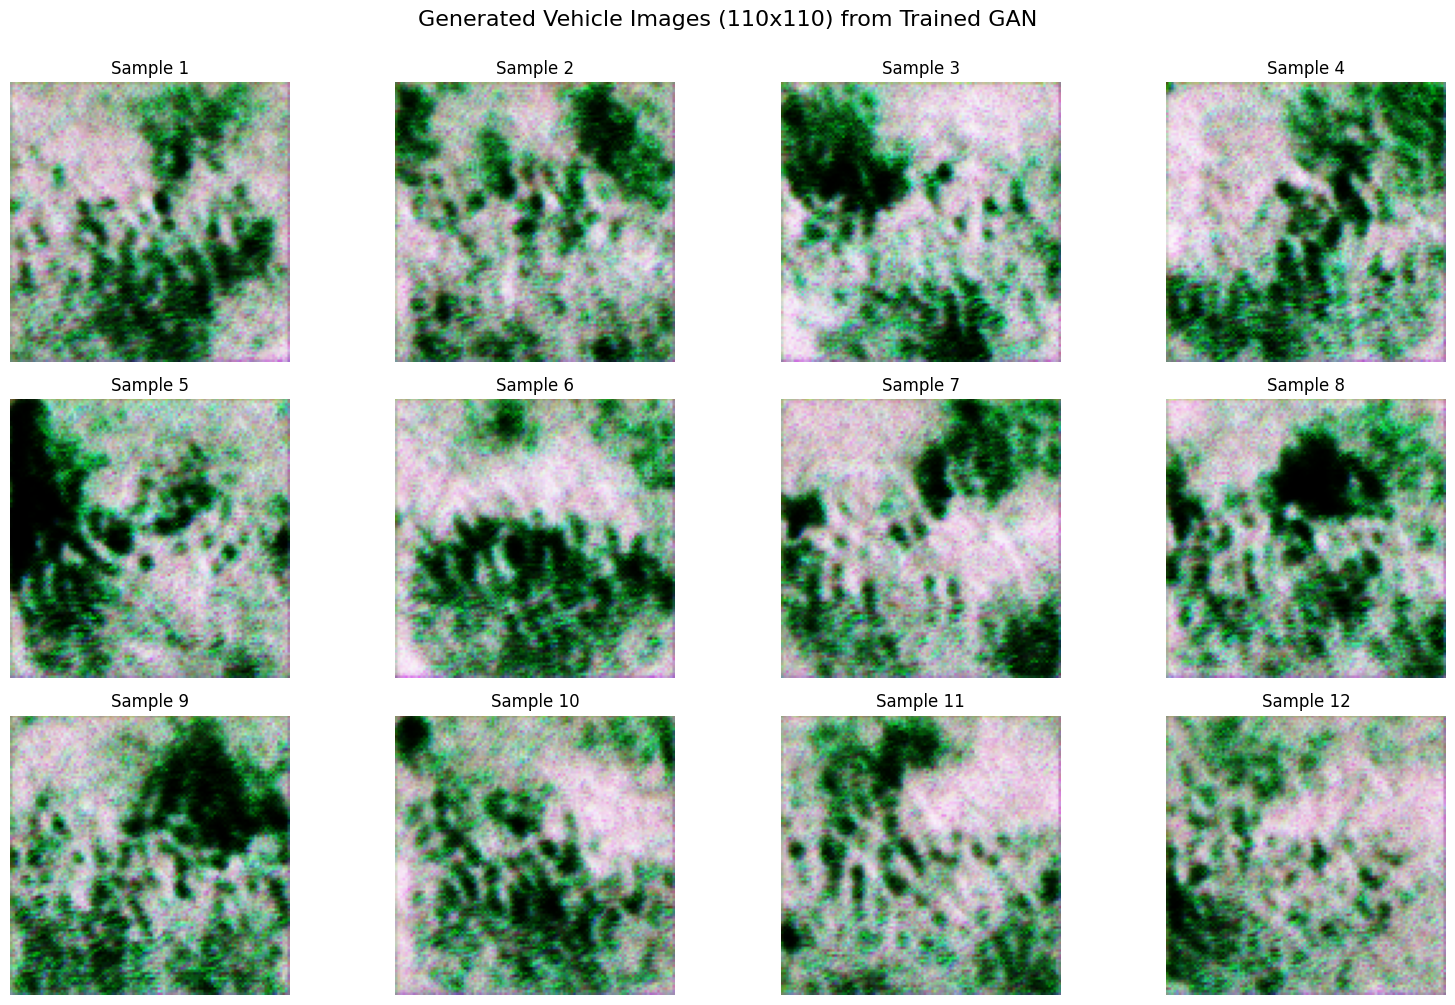


✓ GAN training and generation complete!


In [ ]:
# Save trained models and generate final samples - MUST RUN AFTER TRAINING CELL
if len(gen_losses) > 0 and len(disc_losses) > 0:
    generator_path = os.path.join(MODEL_DIR, 'GAN_generator.keras')
    discriminator_path = os.path.join(MODEL_DIR, 'GAN_discriminator.keras')

    try:
        generator.save(generator_path)
        discriminator.save(discriminator_path)
        print(f"\n✓ Generator saved to: {generator_path}")
        print(f"✓ Discriminator saved to: {discriminator_path}")
    except Exception as e:
        print(f"✗ Error saving models: {e}")

    # Generate final sample images from trained generator
    print("\nGenerating final sample images from trained GAN...")
    num_final_samples = 12
    noise = tf.random.normal([num_final_samples, noise_dim])
    final_images = generator(noise, training=False)

    # Properly normalize images to [0, 1]
    final_images = tf.clip_by_value(final_images, 0.0, 1.0)
    final_images = tf.cast(final_images, tf.float32)

    fig, axes = plt.subplots(3, 4, figsize=(16, 10))
    fig.suptitle('Generated Vehicle Images (110x110) from Trained GAN', fontsize=16, y=1.00)

    for i in range(num_final_samples):
        ax = axes[i // 4, i % 4]
        img = final_images[i].numpy()
        
        # Ensure proper normalization
        if img.shape[-1] == 3:  # RGB image
            if img.min() < 0 or img.max() > 1:
                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        
        ax.imshow(img)
        ax.set_title(f'Sample {i+1}')
        ax.axis('off')

    plt.tight_layout()
    sample_save_path = os.path.join(MODEL_DIR, 'GAN_final_samples_vehicles110.png')
    try:
        plt.savefig(sample_save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Final samples saved to: {sample_save_path}")
    except Exception as e:
        print(f"✗ Error saving samples: {e}")
    plt.show()
    print("\n✓ GAN training and generation complete!")
else:
   
    print("Please run the TRAINING CELL (Cell 10) first to train the GAN.")

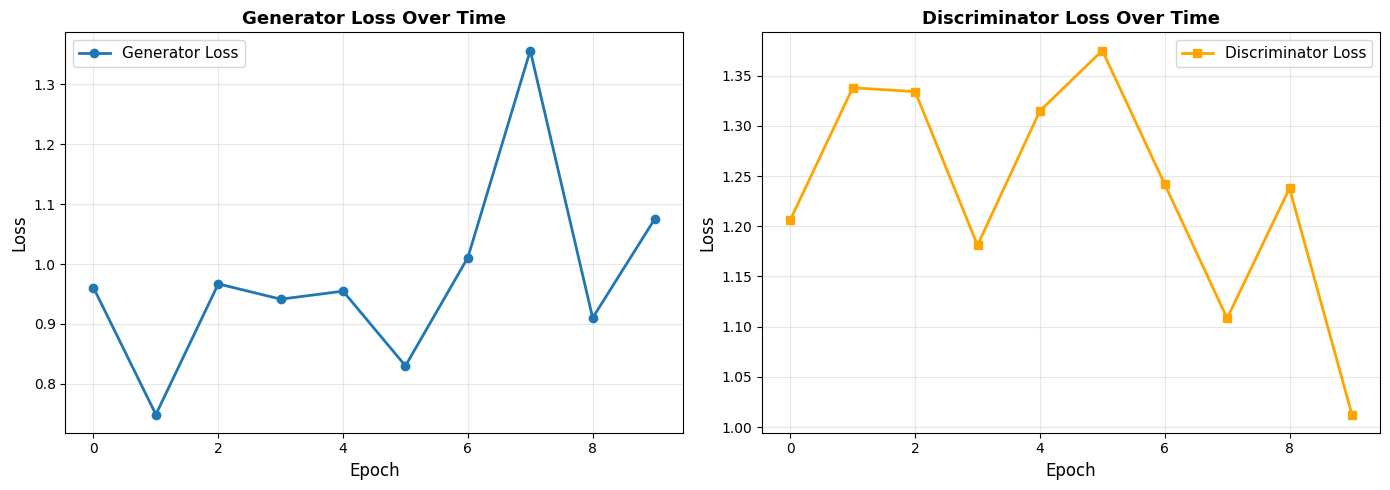


TRAINING SUMMARY
Final Generator Loss:      1.0760
Final Discriminator Loss:  1.0124
Initial Generator Loss:    0.9606
Initial Discriminator Loss: 1.2065
Total Epochs:              10


In [ ]:
# Plot training losses - MUST RUN AFTER TRAINING CELL
if len(gen_losses) > 0 and len(disc_losses) > 0:
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(gen_losses, label='Generator Loss', marker='o', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Generator Loss Over Time', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(disc_losses, label='Discriminator Loss', marker='s', color='orange', linewidth=2)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Discriminator Loss Over Time', fontsize=13, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print("TRAINING SUMMARY")
    print(f"{'='*50}")
    print(f"Final Generator Loss:      {gen_losses[-1]:.4f}")
    print(f"Final Discriminator Loss:  {disc_losses[-1]:.4f}")
    print(f"Initial Generator Loss:    {gen_losses[0]:.4f}")
    print(f"Initial Discriminator Loss: {disc_losses[0]:.4f}")
    print(f"Total Epochs:              {epochs}")
    print(f"{'='*50}")
else:
    print("⚠️  WARNING: No training data available!")
    print("Please run the TRAINING CELL (Cell 10) first to populate gen_losses and disc_losses.")